In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris


In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [ ]:
print("Dataset First 5 Rows")
print(df.head())

print("\nData Information & Missing Values")
print(df.info())

Dataset First 5 Rows
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Data Information & Missing Values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   

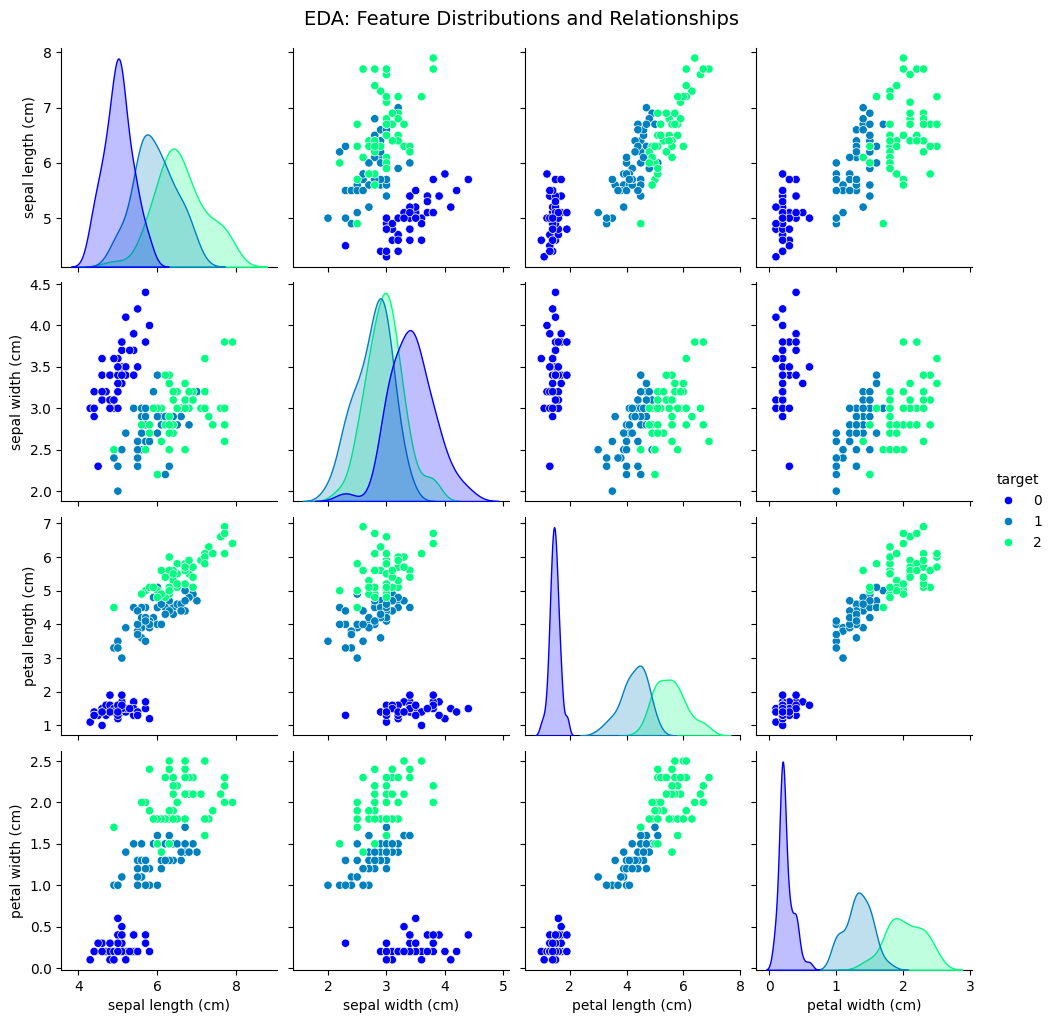

In [ ]:
sns.pairplot(df, hue='target', palette='winter')
plt.suptitle("EDA: Feature Distributions and Relationships", y=1.02, fontsize=14)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, [0, 1]].values
y = df['target'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Data Splitting Shapes")
print(f"X_train Shape: {X_train.shape}  X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}  y_test Shape: {y_test.shape}")

Data Splitting Shapes
X_train Shape: (120, 2)  X_test Shape: (30, 2)
y_train Shape: (120,)  y_test Shape: (30,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize and Train Decision Tree Classifier

dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt_model.fit(X_train, y_train)

# 2. Predictions on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print("Model Evaluation Results")
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")



Model Evaluation Results
Test Accuracy: 66.67%



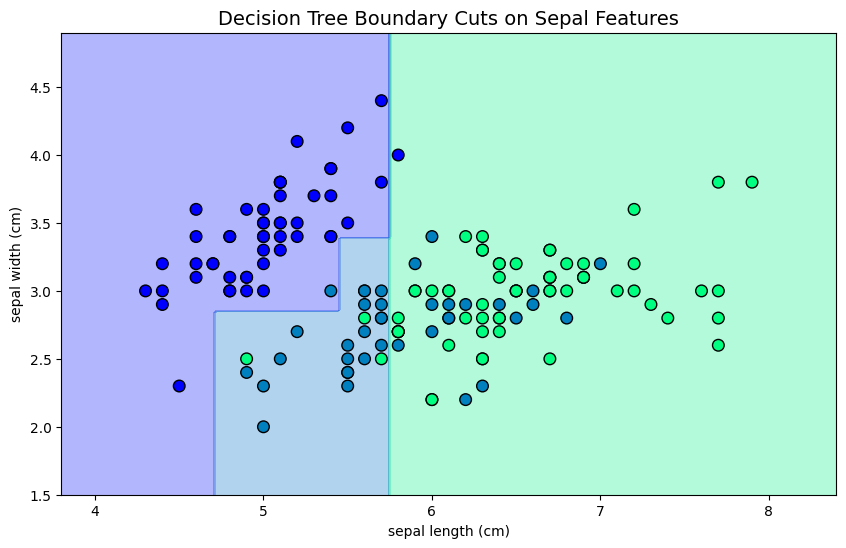

In [ ]:
from sklearn.tree import plot_tree

# 1. Visualizing the Decision Boundary (Axis-Parallel Splits)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='black', s=70)
plt.title("Decision Tree Boundary Cuts on Sepal Features", fontsize=14)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()


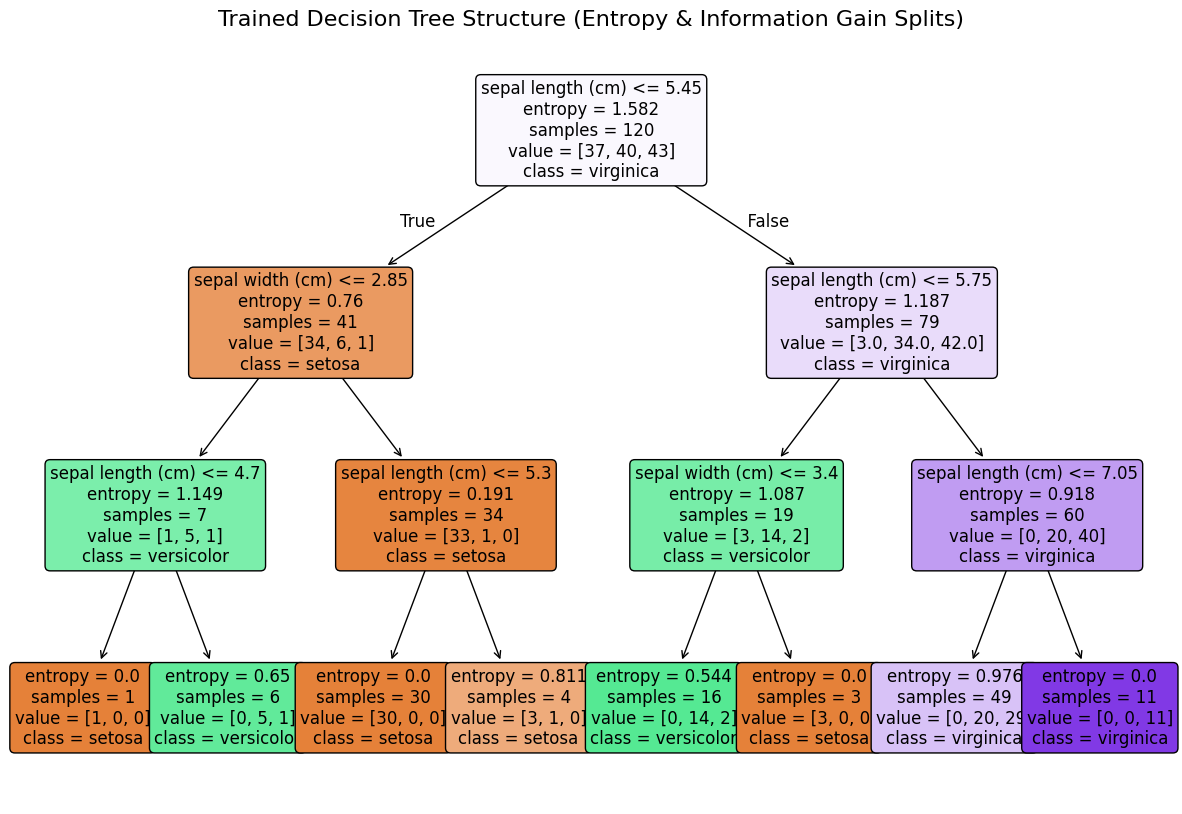

In [ ]:
# 2. Visualizing the Actual Logical Tree Diagram
plt.figure(figsize=(15, 10))
plot_tree(dt_model,
          feature_names=[iris.feature_names[0], iris.feature_names[1]],
          class_names=iris.target_names, filled=True, rounded=True, fontsize=12)
plt.title("Trained Decision Tree Structure (Entropy & Information Gain Splits)", fontsize=16)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model_gini = DecisionTreeClassifier(criterion='gini', max_depth=3)
dt_model_gini.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred_gini = dt_model_gini.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)

print(f"📈 Accuracy with GINI: {acc_gini * 100:.2f}%")


📈 Accuracy with GINI: 76.67%


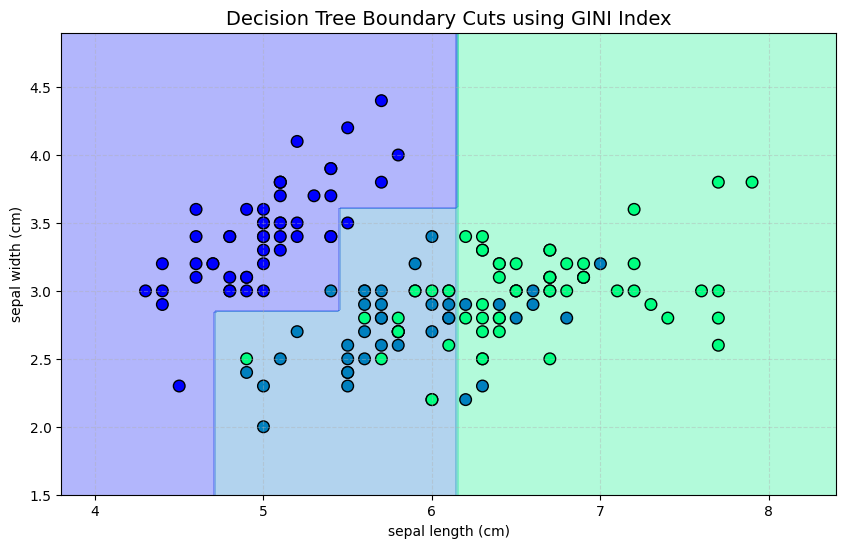

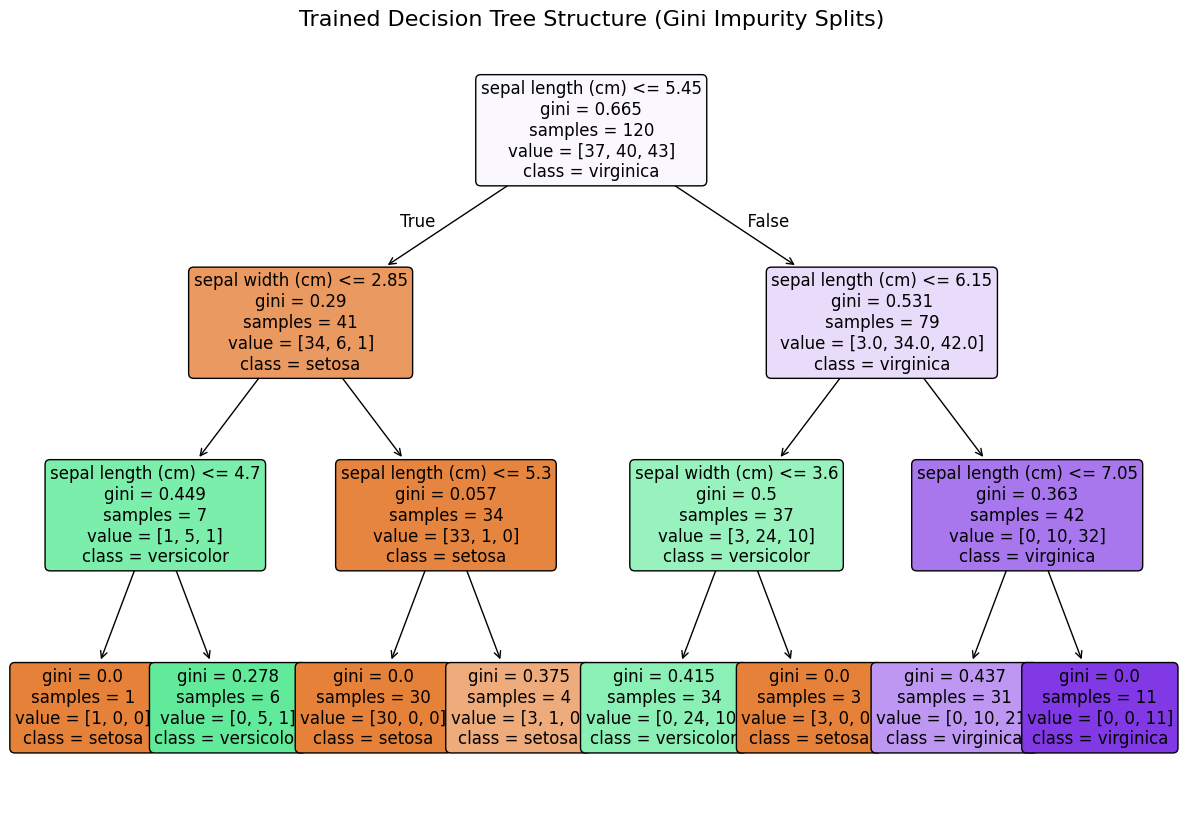

In [ ]:
from sklearn.tree import plot_tree

# 1. Plotting the new Gini Decision Boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = dt_model_gini.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='black', s=70)
plt.title("Decision Tree Boundary Cuts using GINI Index", fontsize=14)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


# 2. Visualizing the Gini Tree Architecture
plt.figure(figsize=(15, 10))
plot_tree(dt_model_gini,
          feature_names=[iris.feature_names[0], iris.feature_names[1]],
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Trained Decision Tree Structure (Gini Impurity Splits)", fontsize=16)
plt.show()